![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [5]:
path = "/Users/ahmadalexander/Desktop/python/eco590/weekly-task-5-Ahmad-Alexander/"
topcities = pd.read_csv(path + "weekly task 5/us-cities-top-1k-multi-year.csv", low_memory=False)
topcities

,City,State,Population,lat,lon,year
0,Marysville,Washington,63269,48.051764,-122.177082,2014
1,Perris,California,72326,33.782519,-117.228648,2014
2,Cleveland,Ohio,390113,41.499320,-81.694361,2014
3,Worcester,Massachusetts,182544,42.262593,-71.802293,2014
4,Columbia,South Carolina,133358,34.000710,-81.034814,2014
...,...,...,...,...,...,...
3995,West New York,New Jersey,724261,40.787879,-74.014306,2018
3996,Everett,Massachusetts,723882,42.408430,-71.053663,2018
3997,Linden,New Jersey,663947,40.622048,-74.244590,2018
3998,Asheville,North Carolina,492462,35.595058,-82.551487,2018


## Question 1:

In [8]:
states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
filtered = topcities[topcities['State'].isin(states)] # filtering to states df
print(filtered['State'].unique())
filtered

['Connecticut' 'Pennsylvania' 'New York' 'New Jersey']


,City,State,Population,lat,lon,year
5,Waterbury,Connecticut,109676,41.558152,-73.051496,2014
33,Allentown,Pennsylvania,118577,40.608430,-75.490183,2014
36,Buffalo,New York,258959,42.886447,-78.878369,2014
44,Mount Vernon,New York,68224,40.912599,-73.837079,2014
48,Stamford,Connecticut,126456,41.053430,-73.538734,2014
...,...,...,...,...,...,...
3949,Vineland,New Jersey,105995,39.486377,-75.025964,2018
3957,Pittsburgh,Pennsylvania,733511,40.440625,-79.995886,2018
3985,New Britain,Connecticut,489575,41.661210,-72.779542,2018
3995,West New York,New Jersey,724261,40.787879,-74.014306,2018


In [16]:
# Aggregatting total population by State and Year
pop_stateyear = filtered.groupby(['State', 'year'])['Population'].sum().reset_index() 
pop_stateyear['year'] = pop_stateyear['year'].astype(int)
print(pop_stateyear)

           State  year  Population
0    Connecticut  2014     1239817
1    Connecticut  2015     5502223
2    Connecticut  2016     7000555
3    Connecticut  2018     7663311
4     New Jersey  2014     1859793
5     New Jersey  2015     8870245
6     New Jersey  2016    10569472
7     New Jersey  2018    10097224
8       New York  2014     9933332
9       New York  2015     5271074
10      New York  2016     8190332
11      New York  2018     9334018
12  Pennsylvania  2014     2598080
13  Pennsylvania  2015     4883554
14  Pennsylvania  2016     5975094
15  Pennsylvania  2018     6463459


In [18]:
print(pop_stateyear['year'].dtype)
print(pop_stateyear['year'].unique())

int64
[2014 2015 2016 2018]


In [14]:
from matplotlib.ticker import StrMethodFormatter

In [24]:
statecolors = {
    'New York':      '#1f77b4',  
    'Pennsylvania':  '#d62728',  
    'Connecticut':   '#2ca02c',  
    'New Jersey':    '#ff7f0e'   
}

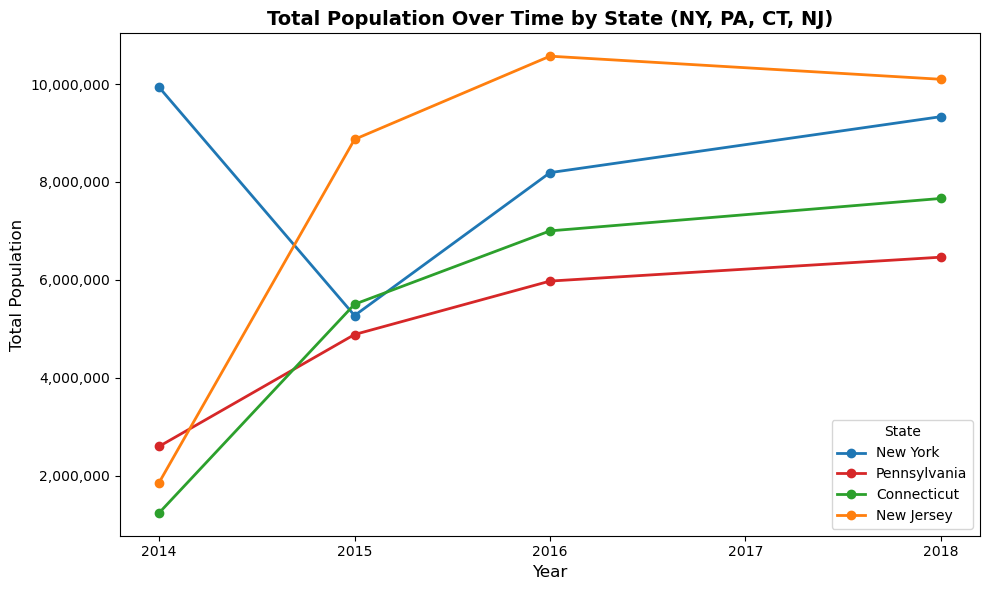

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

for state in states:
    state_data = pop_stateyear[pop_stateyear['State'] == state]
    ax.plot(state_data['year'], state_data['Population'], label=state, marker='o',linewidth=2, color=statecolors[state],)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # formatting y axis, no decimals
ax.set_title('Total Population Over Time by State (NY, PA, CT, NJ)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Population', fontsize=12)
ax.legend(title='State', fontsize=10)
ax.set_xticks([2014, 2015, 2016, 2017, 2018]) # forcing tick spacing (for some reason it was showing up as ex. 2014.0, 2014.5, etc)

plt.tight_layout()
plt.show()

## Question 2:

In [38]:
topnycities = topcities[(topcities['State'] == 'New York') & (topcities['year'].isin([2014, 2018]))]
print(topnycities['City'].unique())
print(topnycities.shape)
topnycities

['Buffalo' 'Mount Vernon' 'Schenectady' 'Binghamton' 'Albany' 'Rochester'
 'Yonkers' 'Niagara Falls' 'Hempstead' 'New Rochelle' 'Troy' 'Syracuse'
 'Valley Stream' 'Freeport' 'White Plains' 'Utica' 'New York']
(34, 6)


,City,State,Population,lat,lon,year
36,Buffalo,New York,258959,42.886447,-78.878369,2014
44,Mount Vernon,New York,68224,40.912599,-73.837079,2014
101,Schenectady,New York,65902,42.814243,-73.939569,2014
156,Binghamton,New York,46444,42.098687,-75.917974,2014
223,Albany,New York,98424,42.652579,-73.756232,2014
247,Rochester,New York,210358,43.161030,-77.610922,2014
295,Yonkers,New York,199766,40.931210,-73.898747,2014
314,Niagara Falls,New York,49468,43.096214,-79.037739,2014
361,Hempstead,New York,55361,40.706213,-73.618740,2014
421,New Rochelle,New York,79446,40.911488,-73.782355,2014


In [39]:
top5 = topnycities.groupby('City')['Population'].sum().nlargest(5).index.tolist() # getting the top 5 cities in ny by pop
print(top5)

['New York', 'Yonkers', 'Freeport', 'Niagara Falls', 'Hempstead']


['New York', 'Yonkers', 'Freeport', 'Niagara Falls', 'Hempstead']

In [40]:
nytop5 = topnycities[topnycities['City'].isin(top5)]
print(nytop5)

               City     State  Population        lat        lon  year
295         Yonkers  New York      199766  40.931210 -73.898747  2014
314   Niagara Falls  New York       49468  43.096214 -79.037739  2014
361       Hempstead  New York       55361  40.706213 -73.618740  2014
668        Freeport  New York       43167  40.657602 -73.583184  2014
890        New York  New York     8405837  40.712784 -74.005941  2014
3295        Yonkers  New York      979707  40.931210 -73.898747  2018
3314  Niagara Falls  New York      944669  43.096214 -79.037739  2018
3361      Hempstead  New York      882502  40.706213 -73.618740  2018
3668       Freeport  New York      982141  40.657602 -73.583183  2018
3890       New York  New York      701573  40.712784 -74.005941  2018


In [44]:
# splitting by year
df_2014 = nytop5[nytop5['year'] == 2014]
df_2018 = nytop5[nytop5['year'] == 2018]

print(df_2014)
print(df_2018)

              City     State  Population        lat        lon  year
295        Yonkers  New York      199766  40.931210 -73.898747  2014
314  Niagara Falls  New York       49468  43.096214 -79.037739  2014
361      Hempstead  New York       55361  40.706213 -73.618740  2014
668       Freeport  New York       43167  40.657602 -73.583184  2014
890       New York  New York     8405837  40.712784 -74.005941  2014
               City     State  Population        lat        lon  year
3295        Yonkers  New York      979707  40.931210 -73.898747  2018
3314  Niagara Falls  New York      944669  43.096214 -79.037739  2018
3361      Hempstead  New York      882502  40.706213 -73.618740  2018
3668       Freeport  New York      982141  40.657602 -73.583183  2018
3890       New York  New York      701573  40.712784 -74.005941  2018


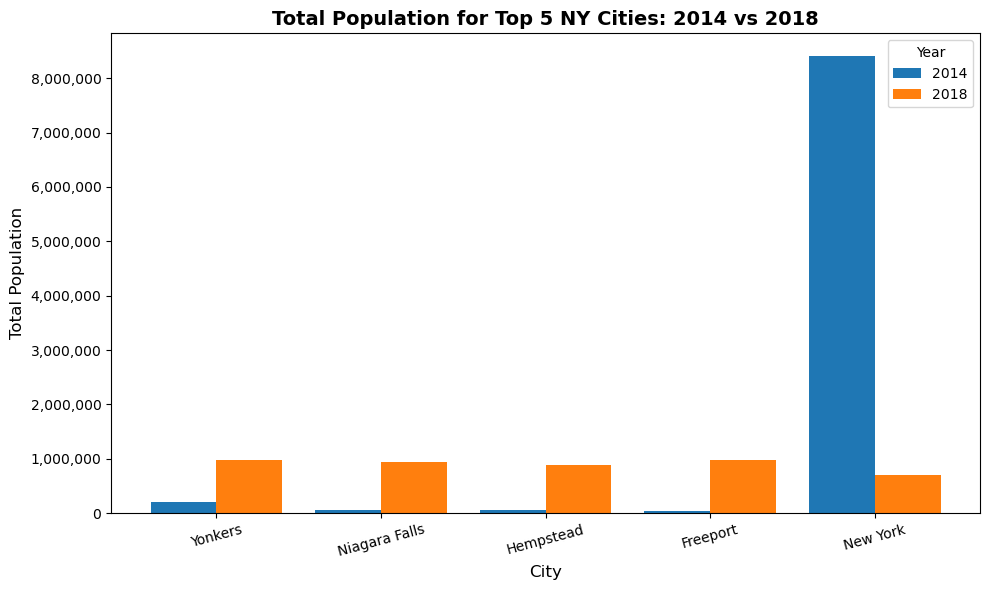

In [46]:
x = np.arange(5)  # setting 5 cities
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.bar(x - 0.2, df_2014['Population'], width=0.4, label='2014', color='#1f77b4')
ax2.bar(x + 0.2, df_2018['Population'], width=0.4, label='2018', color='#ff7f0e')

ax2.set_title('Total Population for Top 5 NY Cities: 2014 vs 2018', fontsize=14, fontweight='bold')
ax2.set_xlabel('City', fontsize=12)
ax2.set_ylabel('Total Population', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(df_2014['City'], rotation=15)
ax2.legend(title='Year', fontsize=10)
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

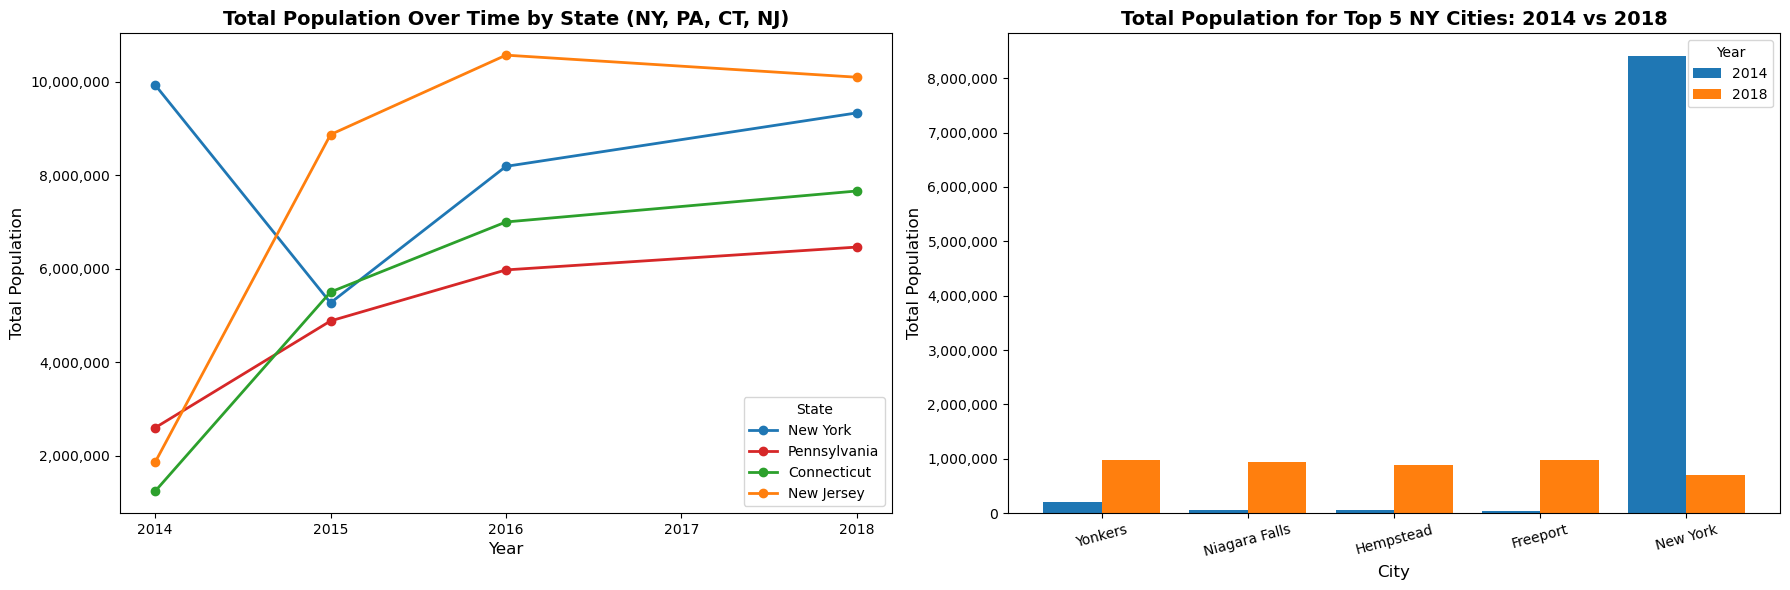

In [48]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 6))

#Graph 1
for state in states:
    state_data = pop_stateyear[pop_stateyear['State'] == state]
    ax.plot(state_data['year'], state_data['Population'], label=state, marker='o',linewidth=2, color=statecolors[state],)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # formatting y axis, no decimals
ax.set_title('Total Population Over Time by State (NY, PA, CT, NJ)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Population', fontsize=12)
ax.legend(title='State', fontsize=10)
ax.set_xticks([2014, 2015, 2016, 2017, 2018]) # forcing tick spacing (for some reason it was showing up as ex. 2014.0, 2014.5, etc)

#Graph 2
x = np.arange(5)
ax2.bar(x - 0.2, df_2014['Population'], width=0.4, label='2014', color='#1f77b4')
ax2.bar(x + 0.2, df_2018['Population'], width=0.4, label='2018', color='#ff7f0e')

ax2.set_title('Total Population for Top 5 NY Cities: 2014 vs 2018', fontsize=14, fontweight='bold')
ax2.set_xlabel('City', fontsize=12)
ax2.set_ylabel('Total Population', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(df_2014['City'], rotation=15)
ax2.legend(title='Year', fontsize=10)
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Question 3:

In [49]:
jobs = pd.read_csv(path + "weekly task 5/job-automation-probability.csv", low_memory=False)
print(jobs.head())
print(jobs.columns.tolist())
jobs

   _ - rank _ - code   prob  Average annual wage  \
0       624  51-4033  0.950              34920.0   
1       517  51-9012  0.880              41450.0   
2       484  41-4012  0.850              68410.0   
3       105  53-1031  0.029              59800.0   
4       620  51-4072  0.950              32660.0   

                           education  \
0  High school diploma or equivalent   
1  High school diploma or equivalent   
2  High school diploma or equivalent   
3  High school diploma or equivalent   
4  High school diploma or equivalent   

                                          occupation  \
0  Grinding, Lapping, Polishing and Buffing Machi...   
1  Separating, Filtering, Clarifying, Precipitati...   
2  Sales Representatives, Wholesale and Manufactu...   
3  First-Line Supervisors of Transportation and M...   
4  Molding, Coremaking and Casting Machine Setter...   

                                    short occupation  len  probability  \
0                Tool setters, oper

,_ - rank,_ - code,prob,Average annual wage,education,occupation,short occupation,len,probability,numbEmployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.9500,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.9500,74600,32890.0,74600,34920.0
1,517,51-9012,0.8800,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.8800,47160,38360.0,47160,41450.0
2,484,41-4012,0.8500,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.8500,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.0290,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.0290,202760,57270.0,202760,59800.0
4,620,51-4072,0.9500,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.9500,145560,30480.0,145560,32660.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,259,27-2011,0.3700,71313.6,"Some college, no degree",Actors,Actors,6,0.3700,48620,33473.0,48620,71313.6
698,522,51-3011,0.8900,27110.0,No formal educational credential,Bakers,Bakers,6,0.8900,180450,25090.0,180450,27110.0
699,42,21-2011,0.0081,49450.0,Bachelor's degree,Clergy,Clergy,6,0.0081,49320,45740.0,49320,49450.0
700,669,41-9012,0.9800,36560.0,No formal educational credential,Models,Models,6,0.9800,4390,21870.0,4390,36560.0


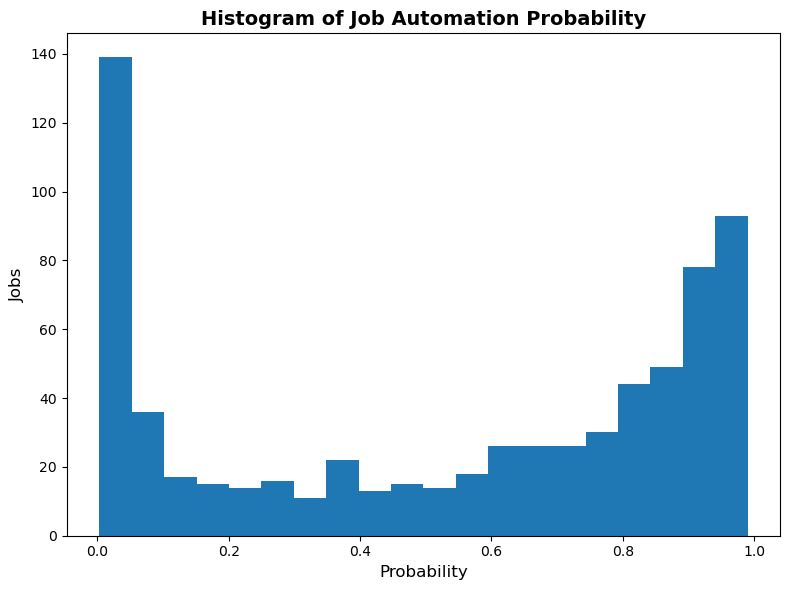

In [51]:
fig, ax3 = plt.subplots(figsize=(8, 6))

ax3.hist(jobs['probability'], bins=20, color='#1f77b4')

ax3.set_title('Histogram of Job Automation Probability', fontsize=14, fontweight='bold')
ax3.set_xlabel('Probability', fontsize=12)
ax3.set_ylabel('Jobs', fontsize=12)

plt.tight_layout()
plt.show()

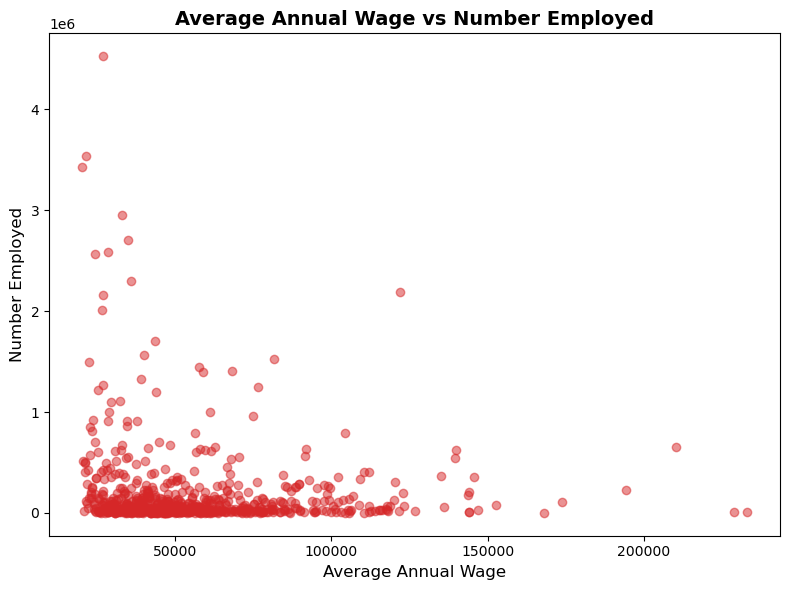

In [54]:
fig, ax4 = plt.subplots(figsize=(8, 6))

ax4.scatter(jobs['Average annual wage'], jobs['numbEmployed'], color='#d62728', alpha=0.5)

ax4.set_title('Average Annual Wage vs Number Employed', fontsize=14, fontweight='bold')
ax4.set_xlabel('Average Annual Wage', fontsize=12)
ax4.set_ylabel('Number Employed', fontsize=12)

plt.tight_layout()
plt.show()

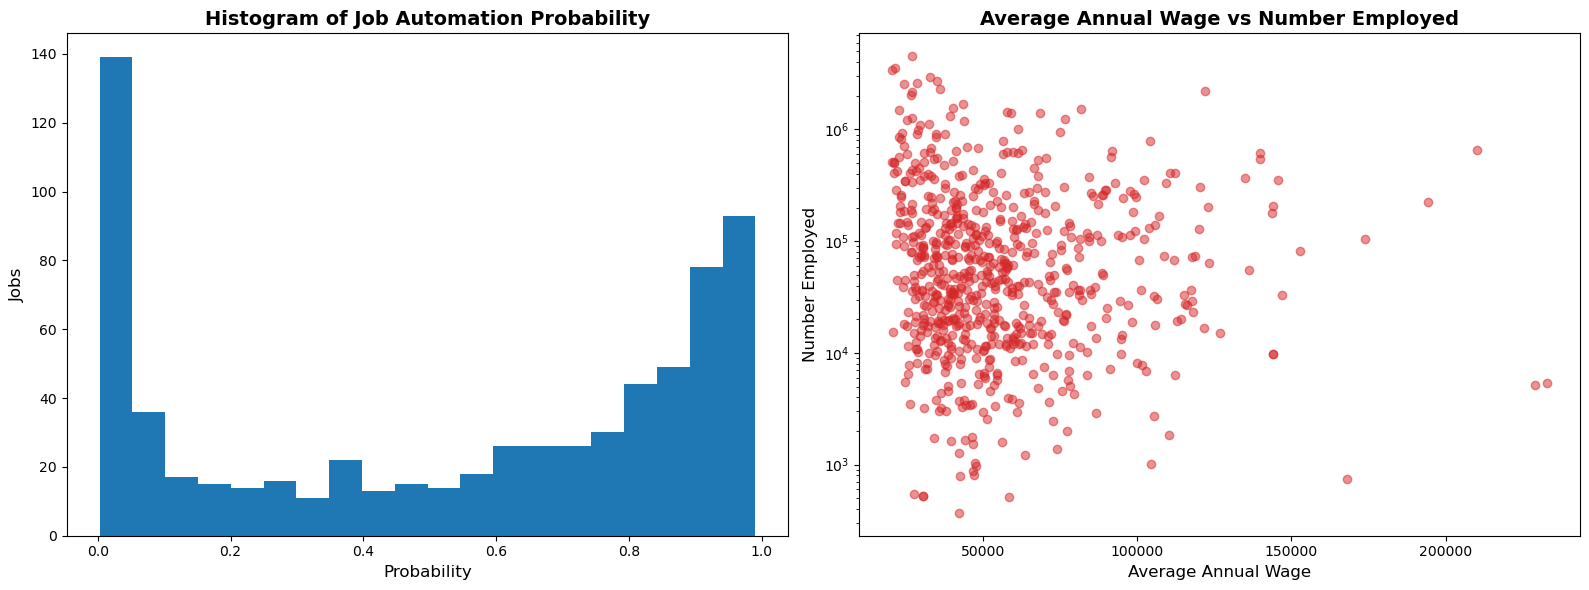

In [58]:
# Combining both graphs
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

#Graph 1:
ax3.hist(jobs['probability'], bins=20, color='#1f77b4')
ax3.set_title('Histogram of Job Automation Probability', fontsize=14, fontweight='bold')
ax3.set_xlabel('Probability', fontsize=12)
ax3.set_ylabel('Jobs', fontsize=12)

#Graph 2:
ax4.scatter(jobs['Average annual wage'], jobs['numbEmployed'], color='#d62728', alpha=0.5)
ax4.set_title('Average Annual Wage vs Number Employed', fontsize=14, fontweight='bold')
ax4.set_xlabel('Average Annual Wage', fontsize=12)
ax4.set_ylabel('Number Employed', fontsize=12)
ax4.set_yscale('log')

plt.tight_layout()
plt.savefig(path + 'job_automation.png', dpi=300, bbox_inches='tight')
plt.show()

## Rescoures:

https://www.geeksforgeeks.org/python/matplotlib-axis-axis-set_major_formatter-function-in-python/

https://stackoverflow.com/questions/76545397/use-format-with-strmethodformatter-in-matplotlib

https://stackoverflow.com/questions/64693136/how-to-properly-use-matplotlibs-set-xticks